# Linear Regression: Predicting Car Fuel Efficiency (Auto MPG)

## Problem Statement
Construct a linear model explaining how a car's mileage (mpg) relates to its attributes (horsepower, weight, displacement, origin, etc.).

## Dataset
**Auto MPG** -- classic UCI dataset of ~398 cars with mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

## Approach
Dropped non-predictive columns (car name, model year), one-hot encoded `origin`, cleaned the `horsepower` column (had `'?'` placeholders for missing values, needed numeric conversion before median imputation), then fit a `LinearRegression` model on a 70/30 train-test split.

## Conclusion
Reports the model's R^2 score on both train and test sets as the headline metric for how well the attributes explain mpg.


In [1]:
#Construct a linear model that explains the relationship a car's mileage(mpg) has with its attributes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
data=pd.read_csv('auto-mpg.csv')

In [4]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
data.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [7]:
data.shape

(398, 9)

In [8]:
data.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [9]:
data.drop(['car name'],axis=1,inplace=True)

In [10]:
data.drop(['model year'],axis=1,inplace=True)

In [11]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin
0,18.0,8,307.0,130,3504,12.0,1
1,15.0,8,350.0,165,3693,11.5,1
2,18.0,8,318.0,150,3436,11.0,1
3,16.0,8,304.0,150,3433,12.0,1
4,17.0,8,302.0,140,3449,10.5,1


In [12]:
#In column origin replace 1 with america,2 with europe and 3 with asia
data['origin']=data['origin'].replace({1:'america',2:'europe',3:'asia'})

In [13]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin
0,18.0,8,307.0,130,3504,12.0,america
1,15.0,8,350.0,165,3693,11.5,america
2,18.0,8,318.0,150,3436,11.0,america
3,16.0,8,304.0,150,3433,12.0,america
4,17.0,8,302.0,140,3449,10.5,america


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   origin        398 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 21.9+ KB


In [15]:
#one hot encoding
data=pd.get_dummies(data,columns=['origin'])

In [16]:
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,1,0,0
1,15.0,8,350.0,165,3693,11.5,1,0,0
2,18.0,8,318.0,150,3436,11.0,1,0,0
3,16.0,8,304.0,150,3433,12.0,1,0,0
4,17.0,8,302.0,140,3449,10.5,1,0,0
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,1,0,0
394,44.0,4,97.0,52,2130,24.6,0,0,1
395,32.0,4,135.0,84,2295,11.6,1,0,0
396,28.0,4,120.0,79,2625,18.6,1,0,0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      398 non-null    object 
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   origin_america  398 non-null    uint8  
 7   origin_asia     398 non-null    uint8  
 8   origin_europe   398 non-null    uint8  
dtypes: float64(3), int64(2), object(1), uint8(3)
memory usage: 19.9+ KB


In [18]:
#isdigit
hp_digit=pd.DataFrame(data.horsepower.str.isdigit())

In [19]:
data[hp_digit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,?,2046,19.0,1,0,0
126,21.0,6,200.0,?,2875,17.0,1,0,0
330,40.9,4,85.0,?,1835,17.3,0,0,1
336,23.6,4,140.0,?,2905,14.3,1,0,0
354,34.5,4,100.0,?,2320,15.8,0,0,1
374,23.0,4,151.0,?,3035,20.5,1,0,0


In [20]:
data=data.replace('?',np.nan)

In [ ]:
# Fixed: convert horsepower to numeric BEFORE computing medians -- 
# it was still 'object' dtype (mixed strings + NaN) at this point, which
# made x.median() fail with "Cannot perform reduction 'median' with string dtype".
data['horsepower'] = data['horsepower'].astype('float64')

In [21]:
data[hp_digit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,NaN,2046,19.0,1,0,0
126,21.0,6,200.0,NaN,2875,17.0,1,0,0
330,40.9,4,85.0,NaN,1835,17.3,0,0,1
336,23.6,4,140.0,NaN,2905,14.3,1,0,0
354,34.5,4,100.0,NaN,2320,15.8,0,0,1
374,23.0,4,151.0,NaN,3035,20.5,1,0,0


In [22]:
#function without any specific names/anonymous functions/Lamda function
#no return statements
#expressed in single lines
p=lambda x:print("square=",x**2)

In [23]:
p(2)

square= 4


In [24]:
replacing=lambda x:x.fillna(x.median())

In [25]:
#apply function is used apply external function:
data=data.apply(replacing)


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      398 non-null    object 
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   origin_america  398 non-null    uint8  
 7   origin_asia     398 non-null    uint8  
 8   origin_europe   398 non-null    uint8  
dtypes: float64(3), int64(2), object(1), uint8(3)
memory usage: 19.9+ KB


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      398 non-null    float64
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   origin_america  398 non-null    uint8  
 7   origin_asia     398 non-null    uint8  
 8   origin_europe   398 non-null    uint8  
dtypes: float64(4), int64(2), uint8(3)
memory usage: 19.9 KB


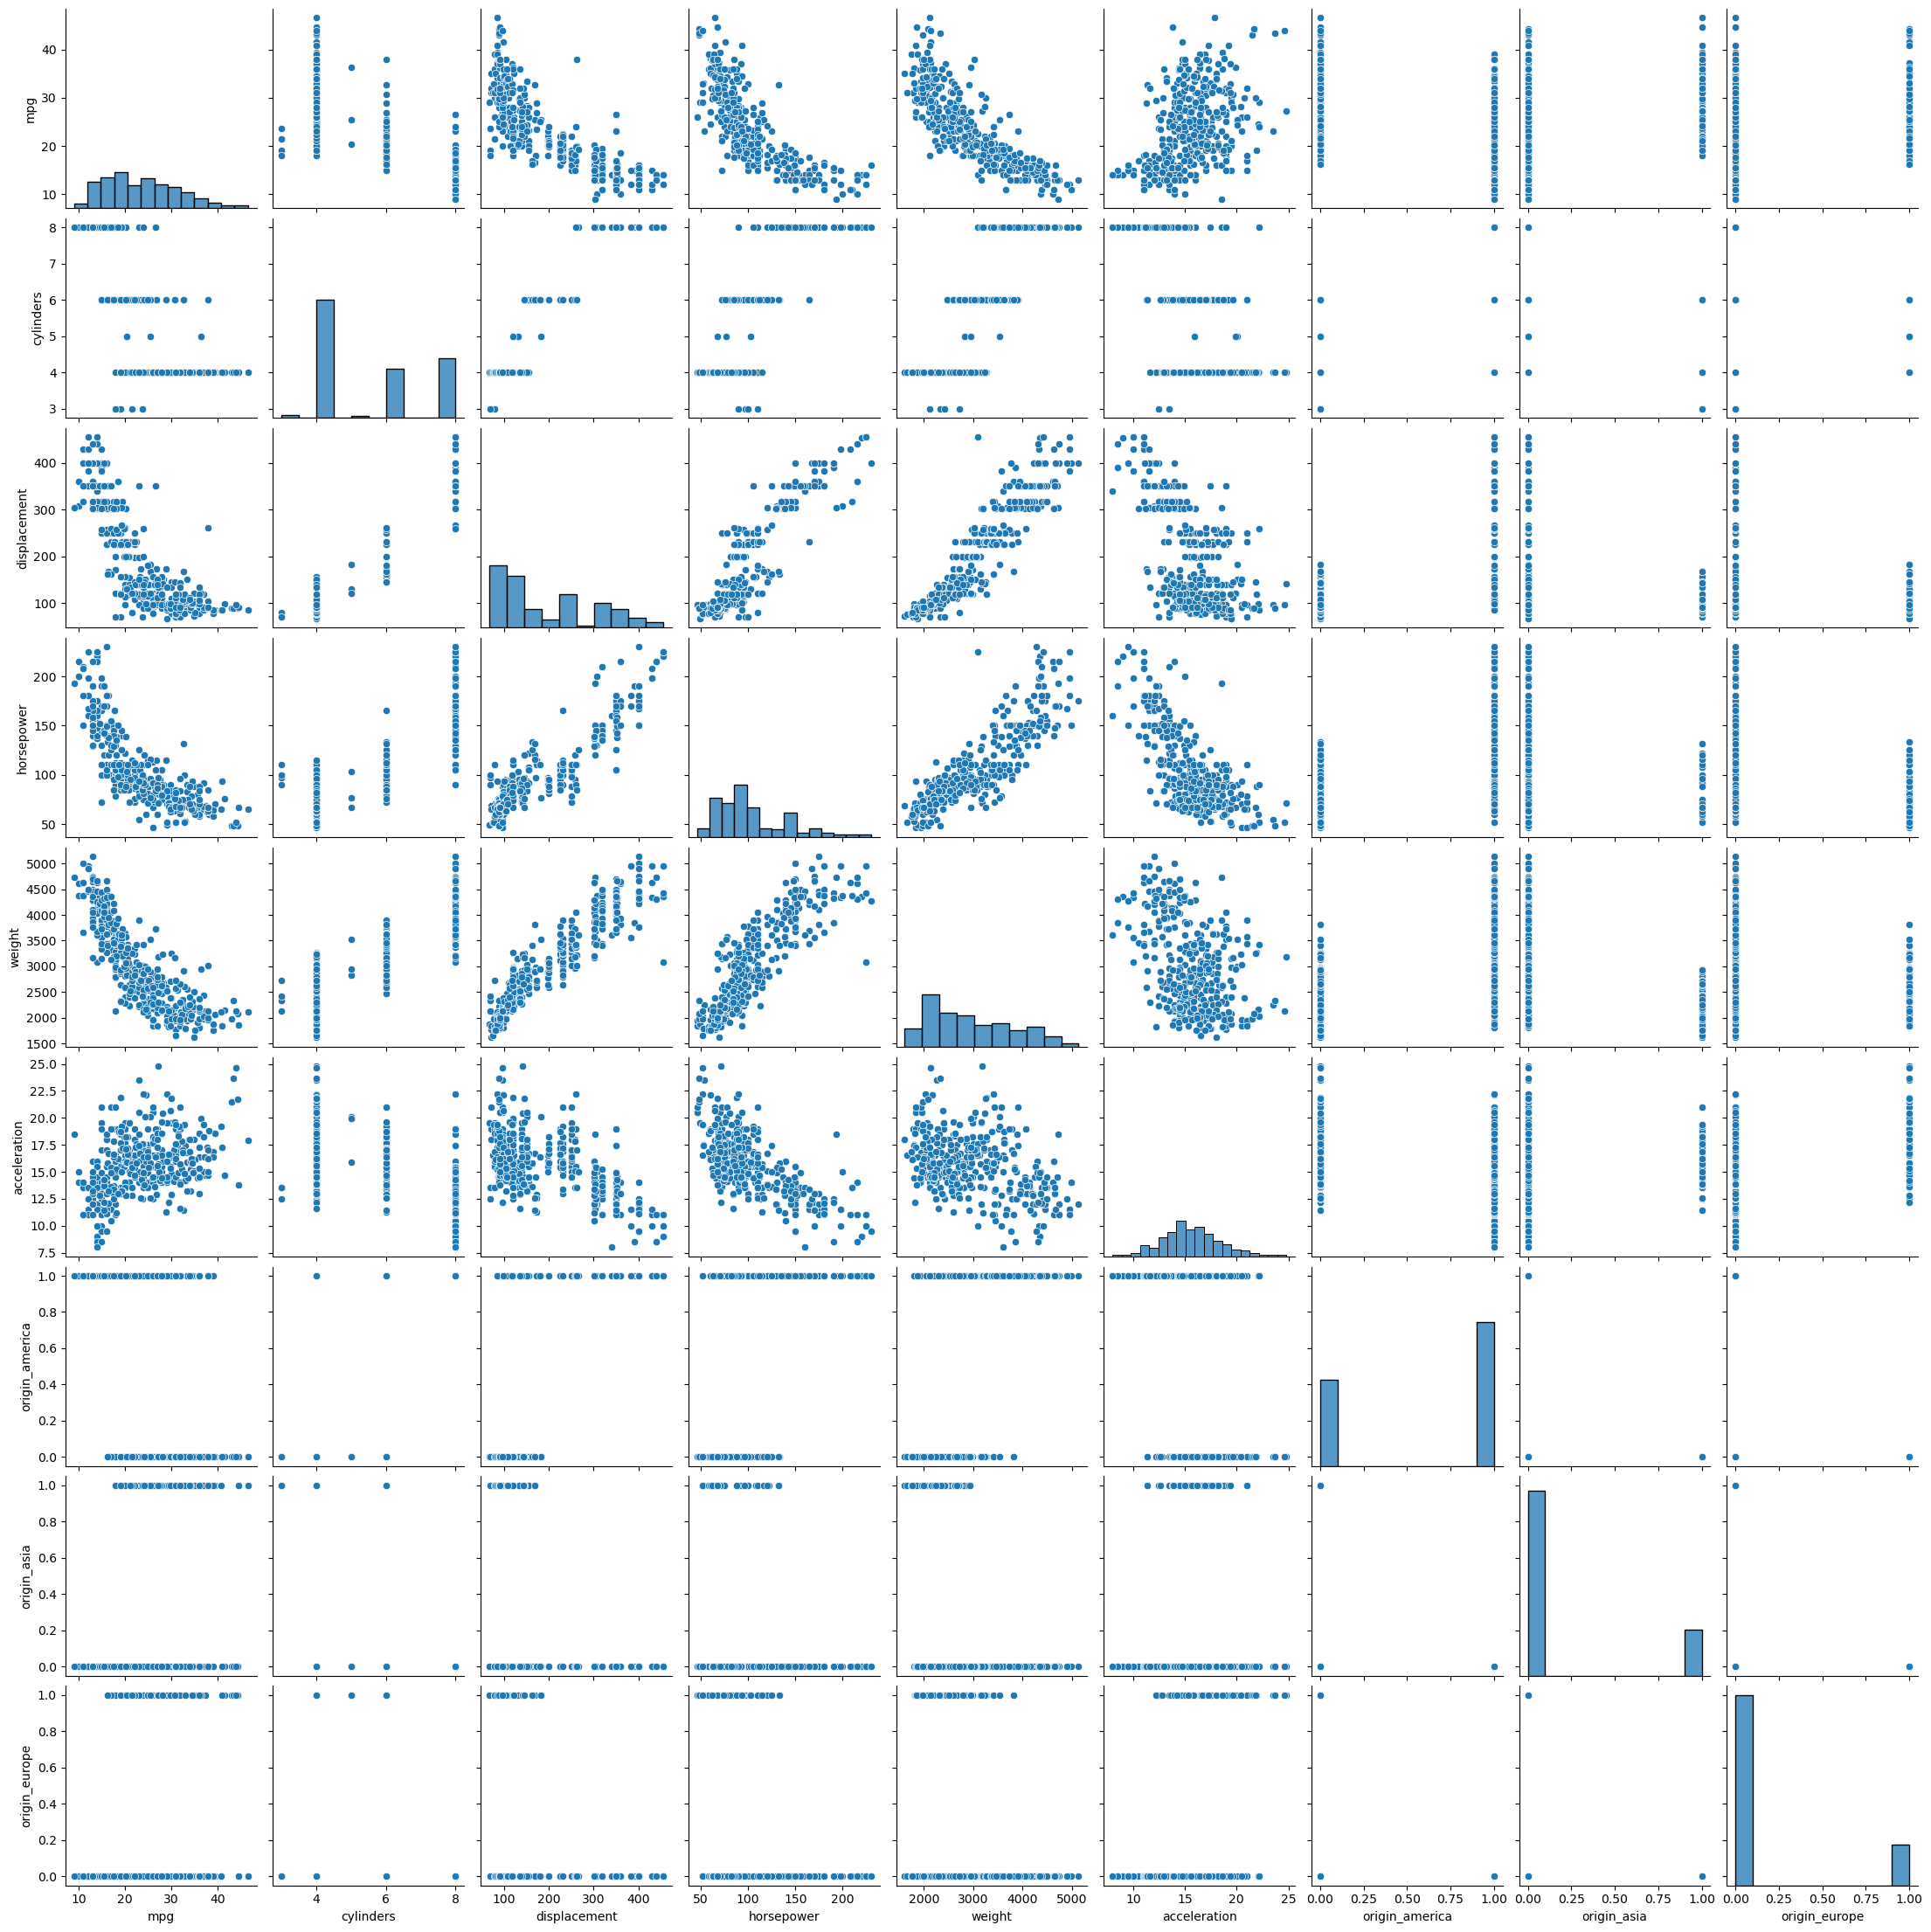

In [30]:
sns.pairplot(data)

In [92]:
data.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,origin_america,origin_asia,origin_europe
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,-0.568192,0.442174,0.259022
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,0.604351,-0.396479,-0.352861
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,0.651407,-0.433505,-0.373886
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,0.485418,-0.318972,-0.282877
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,0.598398,-0.440817,-0.298843
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,-0.250806,0.109144,0.204473
origin_america,-0.568192,0.604351,0.651407,0.485418,0.598398,-0.250806,1.000000,-0.643317,-0.597198
origin_asia,0.442174,-0.396479,-0.433505,-0.318972,-0.440817,0.109144,-0.643317,1.000000,-0.229895
origin_europe,0.259022,-0.352861,-0.373886,-0.282877,-0.298843,0.204473,-0.597198,-0.229895,1.000000


In [93]:
#Splitting dependent & independent variable

In [94]:
x=data.drop('mpg',axis=1)

In [95]:
y=data['mpg']

In [96]:
#seperate your data as train and tested

In [97]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [98]:
#Apply the algorithm to the data

In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
regression_model=LinearRegression()

In [109]:
regression_model.fit(x_train,y_train)

LinearRegression()

In [110]:
#Evaluate model
regression_model.score(x_test,y_test)

0.7725116212499805

In [111]:
regression_model.score(x_train,y_train)

0.6946279278265037